# Advanced Analytics Pipeline: Regression, Classification, and Clustering
## 2026 Bangladesh National Election & July Charter Referendum

This notebook executes six distinct analytical tasks across regression, classification, and clustering domains using PySpark MLlib.
The objective is to uncover deep socio-political insights utilizing the 18 engineered socio-economic indicators and concurrent referendum outcomes.


In [1]:
!pip install pyspark -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, StringType

from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, PCA
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName("Advanced_Analytics_Pipeline").getOrCreate()

# Visualization Configuration
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 120,
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.grid': True, 'grid.alpha': 0.3
})

PALETTE_BNP = '#1B5E20'
PALETTE_JAMAAT = '#B71C1C'
PALETTE_ACCENT = '#1565C0'
PALETTE_NEUTRAL = '#37474F'

print("Environment setup complete.")

Environment setup complete.


In [2]:
# Load the enriched dataframe
data_path = "/content/grand_df_enriched.csv"
try:
    grand_df = spark.read.csv(data_path, header=True, inferSchema=True)
    print(f"Successfully loaded dataset with {grand_df.count()} rows.")
except Exception as e:
    print(f"Error loading data: {e}")
    print(f"Please ensure '{data_path}' is available in the current directory.")

BASE_FEATURES = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "WPI_Log", "Organized_Learning_Pct", "Sanitation_Pct", "Electricity_Pct",
    "Clean_Fuel_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite",
    "Deprivation_Index"
]

# Ensure correct data types for processing
for f in BASE_FEATURES + ["Voter_Turnout_Pct", "YES_Pct", "NO_Pct", "Victory_Margin_Pct", "Winner_Vote_Share_Pct"]:
    if f in grand_df.columns:
        grand_df = grand_df.withColumn(f, F.col(f).cast(DoubleType()))


Successfully loaded dataset with 269 rows.


## PART 1: REGRESSION ANALYSIS
### Task 1.1: Referendum Support Percentage Prediction

**Objective**: Predict the percentage of people who participated in the referendum.
**Methodology**: Linear Regression predicting `Voter_Turnout_Pct` (filtered for the seats with referendum data) using education (`Organized_Learning_Pct`), urbanization (`Urban_Proxy`), and infrastructure (`Electricity_Pct`).
**Insight**: This analysis isolates the specific demographic traits that drive civic participation in national constitutional decisions, controlling for poverty and partisan effects.


TASK 1.1: REFERENDUM SUPPORT PERCENTAGE PREDICTION
Evaluating on 168 constituencies with Referendum data.
RMSE: 7.9103
R-squared: 0.2836


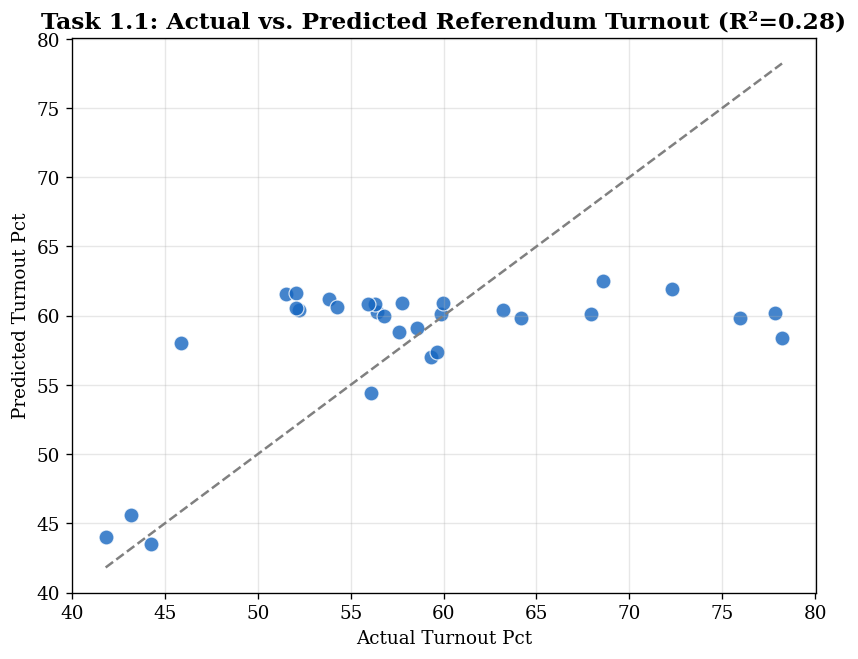

In [3]:
print("=" * 80)
print("TASK 1.1: REFERENDUM SUPPORT PERCENTAGE PREDICTION")
print("=" * 80)

# Filter for referendum seats and drop nulls in target/features
features_1_1 = ["Organized_Learning_Pct", "Urban_Proxy", "Electricity_Pct"]
df_1_1 = grand_df.filter(F.col("YES_Pct").isNotNull()).select(features_1_1 + ["Voter_Turnout_Pct"]).dropna()
print(f"Evaluating on {df_1_1.count()} constituencies with Referendum data.")

assembler_1_1 = VectorAssembler(inputCols=features_1_1, outputCol="features")
lr_1_1 = LinearRegression(featuresCol="features", labelCol="Voter_Turnout_Pct")
pipe_1_1 = Pipeline(stages=[assembler_1_1, lr_1_1])

# Train-test split
train_1_1, test_1_1 = df_1_1.randomSplit([0.8, 0.2], seed=488)
model_1_1 = pipe_1_1.fit(train_1_1)
preds_1_1 = model_1_1.transform(test_1_1)

eval_rmse = RegressionEvaluator(labelCol="Voter_Turnout_Pct", predictionCol="prediction", metricName="rmse")
eval_r2 = RegressionEvaluator(labelCol="Voter_Turnout_Pct", predictionCol="prediction", metricName="r2")

rmse_1_1 = eval_rmse.evaluate(preds_1_1)
r2_1_1 = eval_r2.evaluate(preds_1_1)

print(f"RMSE: {rmse_1_1:.4f}")
print(f"R-squared: {r2_1_1:.4f}")

# Visualization
preds_pdf_1_1 = preds_1_1.select("Voter_Turnout_Pct", "prediction").toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=preds_pdf_1_1, x="Voter_Turnout_Pct", y="prediction", color=PALETTE_ACCENT, alpha=0.8, s=80, ax=ax)

# Identity line
min_val = min(preds_pdf_1_1["Voter_Turnout_Pct"].min(), preds_pdf_1_1["prediction"].min())
max_val = max(preds_pdf_1_1["Voter_Turnout_Pct"].max(), preds_pdf_1_1["prediction"].max())
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')

ax.set_xlabel("Actual Turnout Pct")
ax.set_ylabel("Predicted Turnout Pct")
ax.set_title(f"Task 1.1: Actual vs. Predicted Referendum Turnout (R²={r2_1_1:.2f})")
plt.show()

### Task 1.2: Winning Margin Prediction

**Objective**: Predict the `Victory_Margin_Pct` (the vote difference between the winner and runner-up).
**Methodology**: Random Forest Regression utilizing the 18 base socio-economic features plus the referendum split (`YES_Pct` and `NO_Pct`).
**Insight**: Identifies the demographic blueprints of "landslide" constituencies versus highly competitive, fractured constituencies.


TASK 1.2: WINNING MARGIN PREDICTION
Evaluating on 168 constituencies with complete data.
RMSE: 15.8063
R-squared: 0.0162


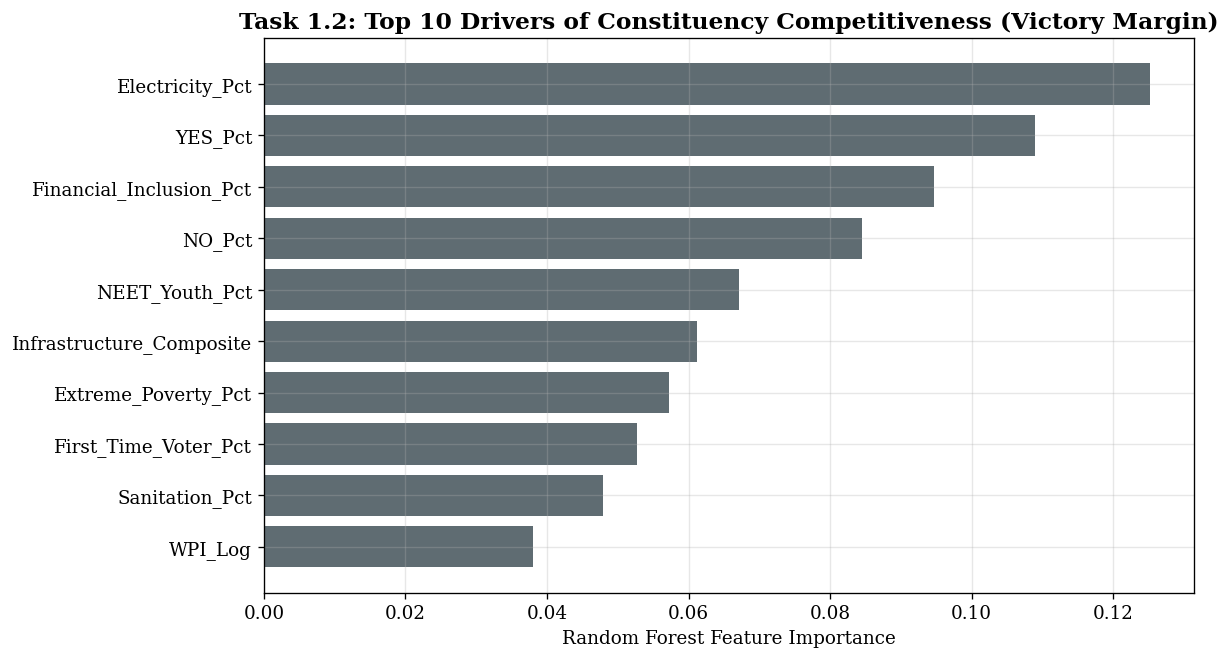

In [4]:
print("=" * 80)
print("TASK 1.2: WINNING MARGIN PREDICTION")
print("=" * 80)

features_1_2 = BASE_FEATURES + ["YES_Pct", "NO_Pct"]
df_1_2 = grand_df.select(features_1_2 + ["Victory_Margin_Pct"]).dropna()
print(f"Evaluating on {df_1_2.count()} constituencies with complete data.")

assembler_1_2 = VectorAssembler(inputCols=features_1_2, outputCol="features")
rf_1_2 = RandomForestRegressor(featuresCol="features", labelCol="Victory_Margin_Pct", numTrees=100, seed=488)
pipe_1_2 = Pipeline(stages=[assembler_1_2, rf_1_2])

train_1_2, test_1_2 = df_1_2.randomSplit([0.8, 0.2], seed=488)
model_1_2 = pipe_1_2.fit(train_1_2)
preds_1_2 = model_1_2.transform(test_1_2)

rmse_1_2 = eval_rmse.setLabelCol("Victory_Margin_Pct").evaluate(preds_1_2)
r2_1_2 = eval_r2.setLabelCol("Victory_Margin_Pct").evaluate(preds_1_2)

print(f"RMSE: {rmse_1_2:.4f}")
print(f"R-squared: {r2_1_2:.4f}")

# Feature Importances
importances_1_2 = model_1_2.stages[-1].featureImportances.toArray()
fi_df_1_2 = pd.DataFrame({'Feature': features_1_2, 'Importance': importances_1_2})
fi_df_1_2 = fi_df_1_2.sort_values('Importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df_1_2['Feature'], fi_df_1_2['Importance'], color=PALETTE_NEUTRAL, alpha=0.8)
ax.set_xlabel("Random Forest Feature Importance")
ax.set_title("Task 1.2: Top 10 Drivers of Constituency Competitiveness (Victory Margin)")
plt.show()

## PART 2: CLASSIFICATION ANALYSIS
### Task 2.1: Referendum Outcome Classification

**Objective**: Classify whether a constituency voted majority "YES" or majority "NO" on the July Charter.
**Methodology**: Train a Random Forest Classification model on the 18 base features predicting a dynamically engineered binary target `Referendum_Majority_YES`.
**Insight**: Discovers if the constitutional referendum outcome can be purely predicted by the underlying demographic fabric of the constituency.


TASK 2.1: REFERENDUM OUTCOME CLASSIFICATION
Evaluating on 168 constituencies.
Accuracy: 0.9000
AUC-ROC: 0.9136


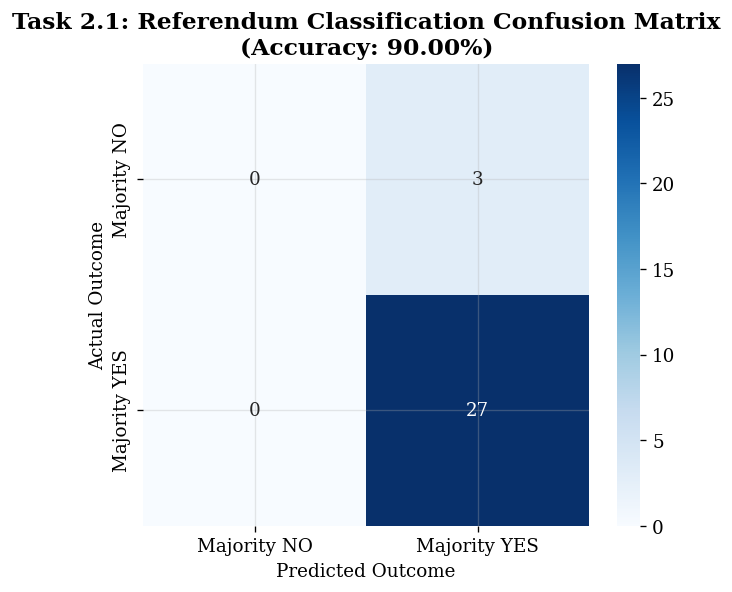

In [5]:
print("=" * 80)
print("TASK 2.1: REFERENDUM OUTCOME CLASSIFICATION")
print("=" * 80)

from sklearn.metrics import confusion_matrix

df_2_1 = grand_df.filter(F.col("YES_Pct").isNotNull()).withColumn(
    "Referendum_Majority_YES",
    F.when(F.col("YES_Pct") > F.col("NO_Pct"), 1.0).otherwise(0.0)
).select(BASE_FEATURES + ["Referendum_Majority_YES"]).dropna()

print(f"Evaluating on {df_2_1.count()} constituencies.")

assembler_2_1 = VectorAssembler(inputCols=BASE_FEATURES, outputCol="features")
rf_2_1 = RandomForestClassifier(featuresCol="features", labelCol="Referendum_Majority_YES", numTrees=100, seed=488)
pipe_2_1 = Pipeline(stages=[assembler_2_1, rf_2_1])

train_2_1, test_2_1 = df_2_1.randomSplit([0.8, 0.2], seed=488)
model_2_1 = pipe_2_1.fit(train_2_1)
preds_2_1 = model_2_1.transform(test_2_1)

eval_acc = MulticlassClassificationEvaluator(labelCol="Referendum_Majority_YES", predictionCol="prediction", metricName="accuracy")
eval_auc = BinaryClassificationEvaluator(labelCol="Referendum_Majority_YES", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

acc_2_1 = eval_acc.evaluate(preds_2_1)
auc_2_1 = eval_auc.evaluate(preds_2_1)

print(f"Accuracy: {acc_2_1:.4f}")
print(f"AUC-ROC: {auc_2_1:.4f}")

# Confusion Matrix
preds_pdf_2_1 = preds_2_1.select("Referendum_Majority_YES", "prediction").toPandas()
cm_2_1 = confusion_matrix(preds_pdf_2_1["Referendum_Majority_YES"], preds_pdf_2_1["prediction"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_2_1, annot=True, fmt='d', cmap="Blues", ax=ax,
            xticklabels=["Majority NO", "Majority YES"],
            yticklabels=["Majority NO", "Majority YES"])
ax.set_ylabel("Actual Outcome")
ax.set_xlabel("Predicted Outcome")
ax.set_title(f"Task 2.1: Referendum Classification Confusion Matrix\n(Accuracy: {acc_2_1:.2%})")
plt.show()

### Task 2.2: Winning Party Prediction

**Objective**: Predict the winning political bloc across three classes (`BNP_COALITION`, `JAMAAT_REFORM`, `INDEPENDENT_OTHER`).
**Methodology**: Multi-class Random Forest predicting the `Coalition` label using the 18 socio-economic features plus the referendum outcomes (`YES_Pct`, `NO_Pct`).
**Insight**: Determines if the constitutional referendum sentiment is a stronger predictor of political alignment than raw demographic and poverty metrics.


TASK 2.2: WINNING PARTY PREDICTION
Evaluating on 168 constituencies with complete data.
Multi-class Accuracy: 0.8000
F1-Score: 0.7643


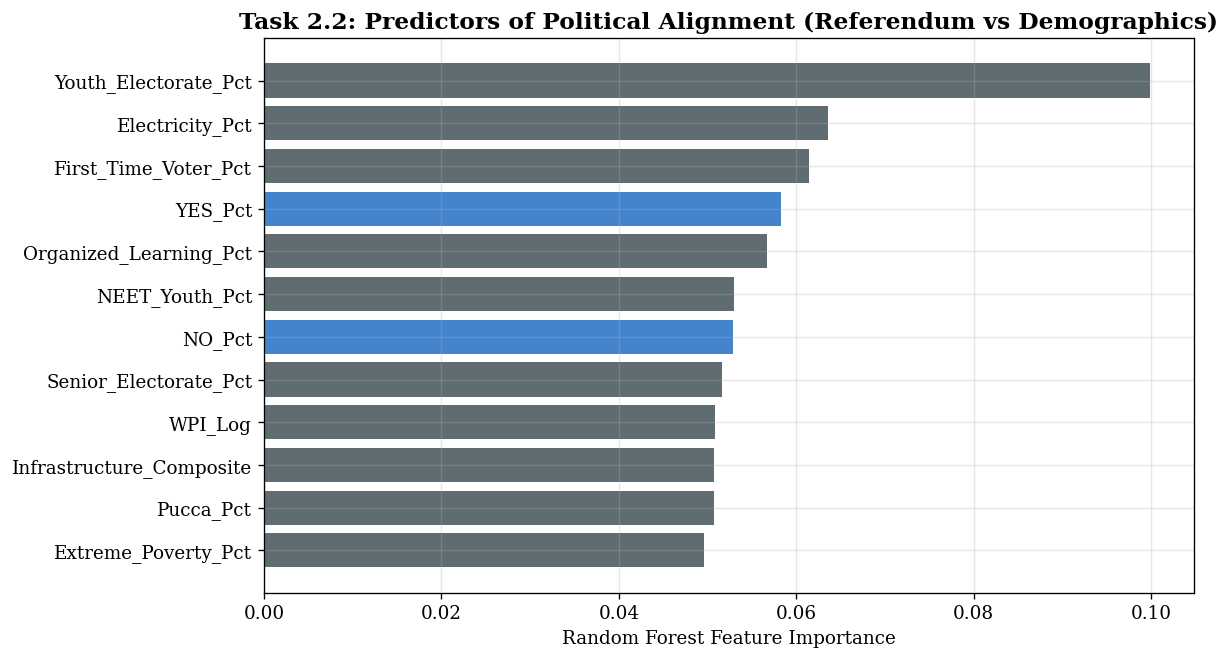

In [7]:
print("=" * 80)
print("TASK 2.2: WINNING PARTY PREDICTION")
print("=" * 80)

features_2_2 = BASE_FEATURES + ["YES_Pct", "NO_Pct"]
df_2_2 = grand_df.filter(F.col("Coalition").isNotNull()).select(features_2_2 + ["Coalition"]).dropna()

# FIX: Fit the model once, extract labels, then transform
indexer_2_2 = StringIndexer(inputCol="Coalition", outputCol="label")
indexer_model_2_2 = indexer_2_2.fit(df_2_2)
labels_2_2 = indexer_model_2_2.labels
df_2_2 = indexer_model_2_2.transform(df_2_2)

print(f"Evaluating on {df_2_2.count()} constituencies with complete data.")

assembler_2_2 = VectorAssembler(inputCols=features_2_2, outputCol="features")
rf_2_2 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=150, maxDepth=6, seed=488)
pipe_2_2 = Pipeline(stages=[assembler_2_2, rf_2_2])

train_2_2, test_2_2 = df_2_2.randomSplit([0.8, 0.2], seed=488)
model_2_2 = pipe_2_2.fit(train_2_2)
preds_2_2 = model_2_2.transform(test_2_2)

eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
acc_2_2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(preds_2_2)
f1_2_2 = eval_f1.evaluate(preds_2_2)

print(f"Multi-class Accuracy: {acc_2_2:.4f}")
print(f"F1-Score: {f1_2_2:.4f}")

# Feature Importances
importances_2_2 = model_2_2.stages[-1].featureImportances.toArray()
fi_df_2_2 = pd.DataFrame({'Feature': features_2_2, 'Importance': importances_2_2})
fi_df_2_2 = fi_df_2_2.sort_values('Importance', ascending=True).tail(12)

colors = [PALETTE_ACCENT if 'Pct' in f and ('YES' in f or 'NO' in f) else PALETTE_NEUTRAL for f in fi_df_2_2['Feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df_2_2['Feature'], fi_df_2_2['Importance'], color=colors, alpha=0.8)
ax.set_xlabel("Random Forest Feature Importance")
ax.set_title("Task 2.2: Predictors of Political Alignment (Referendum vs Demographics)")
plt.show()


### Task 2.3: Voter Behavior Type Classification

**Objective**: Classify constituencies into composite behavioral archetypes.
**Methodology**: Engineer a 4-class target variable based on median splits of `Voter_Turnout_Pct` and Referendum majority (`YES` > `NO`). Train a Random Forest using *only* base demographic features.
**Insight**: Discovers which demographics produce highly active reformists versus apathetic status-quo voters.


TASK 2.3: VOTER BEHAVIOR TYPE CLASSIFICATION
Evaluating on 168 constituencies.
Classification Accuracy for 4 Archetypes: 0.8000


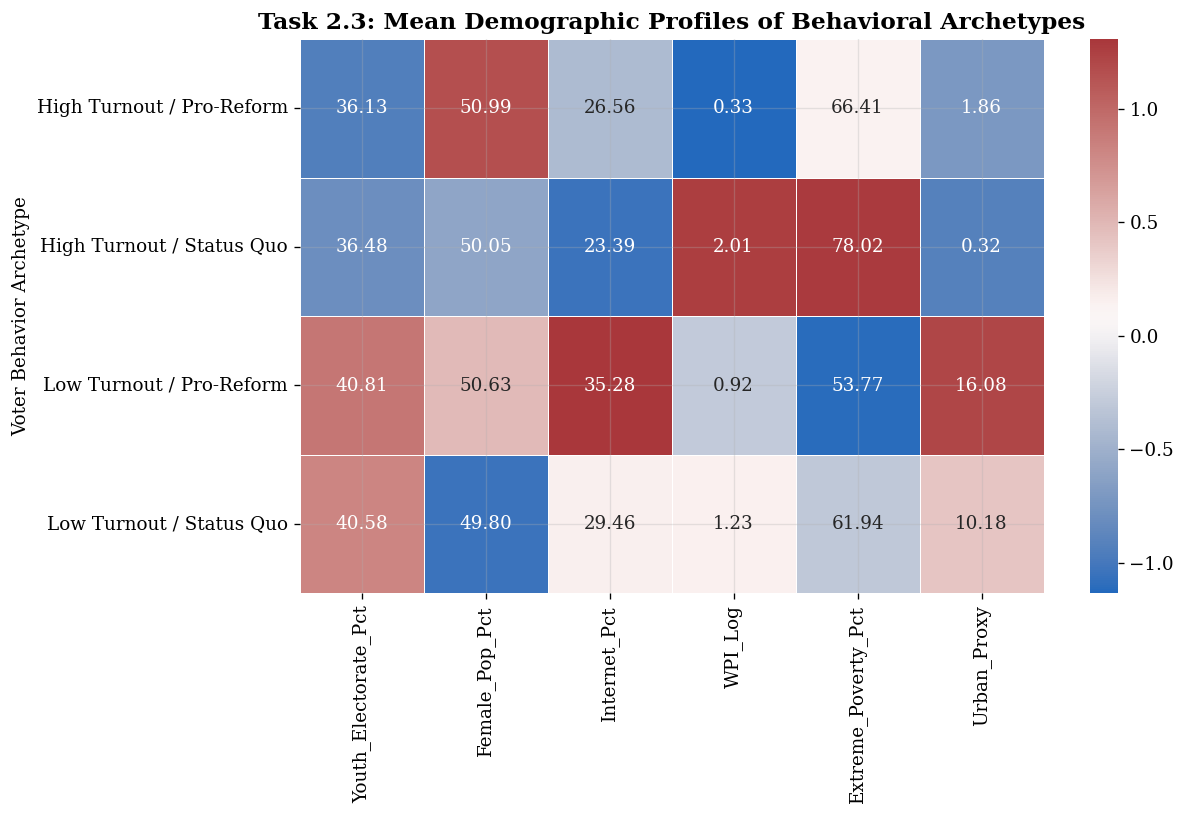

In [8]:
print("=" * 80)
print("TASK 2.3: VOTER BEHAVIOR TYPE CLASSIFICATION")
print("=" * 80)

# Calculate median turnout dynamically
df_valid_turnout = grand_df.filter(F.col("Voter_Turnout_Pct").isNotNull() & F.col("YES_Pct").isNotNull())
med_turnout = df_valid_turnout.approxQuantile("Voter_Turnout_Pct", [0.5], 0.0)[0]

# Engineer 4-class target
df_2_3 = df_valid_turnout.withColumn(
    "Behavior_Archetype",
    F.when((F.col("Voter_Turnout_Pct") > med_turnout) & (F.col("YES_Pct") > F.col("NO_Pct")), "High Turnout / Pro-Reform")
     .when((F.col("Voter_Turnout_Pct") > med_turnout) & (F.col("NO_Pct") > F.col("YES_Pct")), "High Turnout / Status Quo")
     .when((F.col("Voter_Turnout_Pct") <= med_turnout) & (F.col("YES_Pct") > F.col("NO_Pct")), "Low Turnout / Pro-Reform")
     .otherwise("Low Turnout / Status Quo")
).select(BASE_FEATURES + ["Behavior_Archetype"]).dropna()

print(f"Evaluating on {df_2_3.count()} constituencies.")

indexer_2_3 = StringIndexer(inputCol="Behavior_Archetype", outputCol="label")
indexer_model_2_3 = indexer_2_3.fit(df_2_3)
df_2_3 = indexer_model_2_3.transform(df_2_3)

assembler_2_3 = VectorAssembler(inputCols=BASE_FEATURES, outputCol="features")
rf_2_3 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, seed=488)
pipe_2_3 = Pipeline(stages=[assembler_2_3, rf_2_3])

train_2_3, test_2_3 = df_2_3.randomSplit([0.8, 0.2], seed=488)
model_2_3 = pipe_2_3.fit(train_2_3)
preds_2_3 = model_2_3.transform(test_2_3)

acc_2_3 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(preds_2_3)
print(f"Classification Accuracy for 4 Archetypes: {acc_2_3:.4f}")

# Heatmap showing demographic feature means for each of the 4 behavioral classes
pdf_2_3 = df_2_3.toPandas()
# Select a subset of highly interpretable features for the heatmap
heatmap_feats = ["Youth_Electorate_Pct", "Female_Pop_Pct", "Internet_Pct", "WPI_Log", "Extreme_Poverty_Pct", "Urban_Proxy"]
archetype_means = pdf_2_3.groupby("Behavior_Archetype")[heatmap_feats].mean()

# Standardize means across columns for better heatmap contrast
archetype_scaled = (archetype_means - archetype_means.mean()) / archetype_means.std()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(archetype_scaled, annot=archetype_means, fmt=".2f", cmap="vlag", ax=ax, linewidths=.5)
ax.set_ylabel("Voter Behavior Archetype")
ax.set_title("Task 2.3: Mean Demographic Profiles of Behavioral Archetypes")
plt.show()

## PART 3: CLUSTERING ANALYSIS
### Task 3.1: Referendum Alignment Clustering

**Objective**: Group constituencies based entirely on their political and constitutional voting behavior, independent of demographics.
**Methodology**: `StandardScaler` followed by K-Means clustering (K=4) using purely political variables (`Winner_Vote_Share_Pct`, `Victory_Margin_Pct`, `YES_Pct`, `NO_Pct`, `Voter_Turnout_Pct`). Evaluated via Silhouette Score.
**Insight**: Discovers the true "political tribes" of Bangladesh (e.g., highly competitive pro-reform seats vs. uncompetitive anti-reform strongholds).


TASK 3.1: REFERENDUM ALIGNMENT CLUSTERING
Clustering 168 constituencies based on political outcomes.
Silhouette Score (K=4): 0.3776


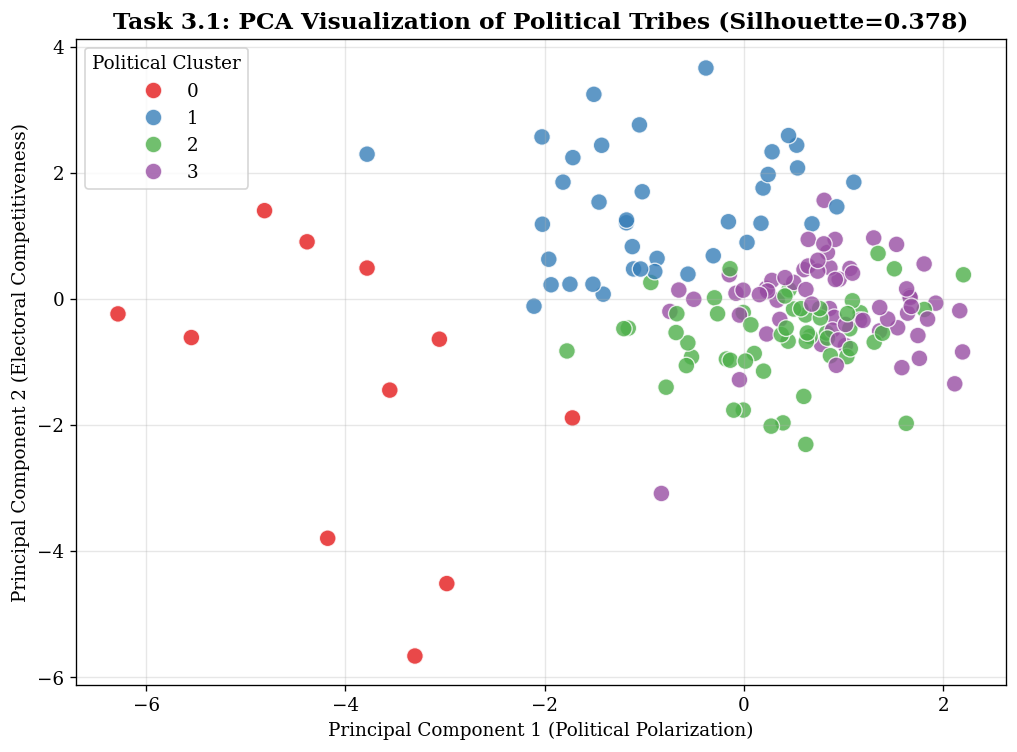


--- MEAN POLITICAL PROFILE BY CLUSTER ---
                   Winner_Vote_Share_Pct  Victory_Margin_Pct  YES_Pct  NO_Pct  \
Political_Cluster                                                               
0                                  60.32               39.31    37.06   62.94   
1                                  67.15               38.83    68.16   31.84   
2                                  51.53               12.18    65.20   34.80   
3                                  51.14               13.69    72.26   27.74   

                   Voter_Turnout_Pct  
Political_Cluster                     
0                              53.85  
1                              57.23  
2                              66.49  
3                              53.90  

--- MEAN DEMOGRAPHIC PROFILE BY CLUSTER (Who lives in these tribes?) ---
                   Internet_Pct  Extreme_Poverty_Pct  Youth_Electorate_Pct  \
Political_Cluster                                                            
0     

In [9]:
print("=" * 80)
print("TASK 3.1: REFERENDUM ALIGNMENT CLUSTERING")
print("=" * 80)

cluster_features = ["Winner_Vote_Share_Pct", "Victory_Margin_Pct", "YES_Pct", "NO_Pct", "Voter_Turnout_Pct"]
df_3_1 = grand_df.select(["Constituency"] + cluster_features + BASE_FEATURES).dropna(subset=cluster_features)

print(f"Clustering {df_3_1.count()} constituencies based on political outcomes.")

assembler_3_1 = VectorAssembler(inputCols=cluster_features, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)
kmeans = KMeans(featuresCol="scaled_features", predictionCol="Political_Cluster", k=4, seed=488)

pipe_3_1 = Pipeline(stages=[assembler_3_1, scaler, kmeans])
model_3_1 = pipe_3_1.fit(df_3_1)
clustered_df = model_3_1.transform(df_3_1)

evaluator = ClusteringEvaluator(predictionCol="Political_Cluster", featuresCol="scaled_features", metricName="silhouette")
silhouette = evaluator.evaluate(clustered_df)
print(f"Silhouette Score (K=4): {silhouette:.4f}")

# PCA for 2D visualization
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(clustered_df)
pca_result = pca_model.transform(clustered_df)

# Extract PCA coordinates into Pandas
pca_pdf = pca_result.select("Constituency", "Political_Cluster", "pca_features").toPandas()
pca_pdf['PC1'] = pca_pdf['pca_features'].apply(lambda x: x[0])
pca_pdf['PC2'] = pca_pdf['pca_features'].apply(lambda x: x[1])

# Plotting PCA Scatter
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_pdf, x='PC1', y='PC2', hue='Political_Cluster', palette="Set1", s=100, alpha=0.8, ax=ax)
ax.set_xlabel("Principal Component 1 (Political Polarization)")
ax.set_ylabel("Principal Component 2 (Electoral Competitiveness)")
ax.set_title(f"Task 3.1: PCA Visualization of Political Tribes (Silhouette={silhouette:.3f})")
plt.legend(title="Political Cluster")
plt.show()

# Output the mean socio-economic profile of each cluster
clustered_pdf = clustered_df.toPandas()
cluster_profile = clustered_pdf.groupby("Political_Cluster")[cluster_features].mean()
print("\n--- MEAN POLITICAL PROFILE BY CLUSTER ---")
print(cluster_profile.round(2))

demo_profile = clustered_pdf.groupby("Political_Cluster")[["Internet_Pct", "Extreme_Poverty_Pct", "Youth_Electorate_Pct", "Urban_Proxy"]].mean()
print("\n--- MEAN DEMOGRAPHIC PROFILE BY CLUSTER (Who lives in these tribes?) ---")
print(demo_profile.round(2))